# Kazakh AI-Generated & AI-Obfuscated Text Detection — Comprehensive EDA

**Project:** Detection of AI-generated and AI-obfuscated text in Kazakh (low-resource, Cyrillic-script).

This notebook is a fully reproducible exploratory data analysis (EDA) over three splits: `train`, `dev`, `test`.
It follows reproducible-research practices: a fixed random seed, modular typed functions, progress bars, and
automatic saving of every figure and table into an output folder.

## Class semantics
The label is inferred from the `source` field and confirmed with the researcher:

| label | name | meaning | typical `source` values |
|------:|------|---------|-------------------------|
| 0 | Human | Original human-written text | `*_text` (e.g. `Conversion_text`, `Summary_text`, `Reading_text`) |
| 1 | AI-Generated | Text produced by an LLM | `*_response` (e.g. `Story_response`, `Reading_response`) |
| 2 | AI-Obfuscated | AI paraphrase / obfuscation of text | `Paraphrase_text2` |

## How to run
Run top to bottom. Heavy sections (transformer tokenizer, sentence-transformer embeddings, t-SNE/UMAP) are
guarded by the `RUN_HEAVY` flag in the config cell — set it to `True` to execute them. All figures are written
to `eda_outputs/figures/` and all tables to `eda_outputs/tables/`.


## 0. Configuration, reproducibility & helpers

We import the scientific-Python stack, fix a global random seed for reproducibility, define the plotting style
for publication-quality figures (300 DPI), and create small helper functions (`save_fig`, `save_table`) that
persist every artifact automatically. The `RUN_HEAVY` flag toggles the compute-intensive sections.


In [1]:
from __future__ import annotations
import os
import re
import json
import math
import string
import random
import warnings
import unicodedata
from pathlib import Path
from collections import Counter
from typing import Callable, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Progress bar with a graceful fallback if tqdm is unavailable.
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x: Iterable, **kwargs):
        return x

# ----------------------------------------------------------------------
# Reproducibility: fix all seeds.
# ----------------------------------------------------------------------
RANDOM_SEED: int = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Toggle compute-heavy sections (Section 9 tokenizer, Section 10 embeddings).
RUN_HEAVY: bool = True

# ----------------------------------------------------------------------
# Plot style (publication quality).
# ----------------------------------------------------------------------
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# ----------------------------------------------------------------------
# Output folders (figures + tables are saved automatically).
# ----------------------------------------------------------------------
OUTPUT_DIR = Path('eda_outputs')
FIG_DIR = OUTPUT_DIR / 'figures'
TAB_DIR = OUTPUT_DIR / 'tables'
for _d in (OUTPUT_DIR, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)

_fig_counter = {'n': 0}

def save_fig(fig: plt.Figure, name: str) -> Path:
    # Save a matplotlib figure to the figures folder with a running index.
    _fig_counter['n'] += 1
    idx = _fig_counter['n']
    fname = FIG_DIR / f'{idx:02d}_{name}.png'
    fig.savefig(fname)
    print(f'[saved figure] {fname}')
    return fname

def save_table(frame: pd.DataFrame, name: str) -> Path:
    # Save a DataFrame to the tables folder as CSV.
    path = TAB_DIR / f'{name}.csv'
    frame.to_csv(path, index=True)
    print(f'[saved table] {path}')
    return path

# Canonical class names and a colour-blind-friendly palette.
LABEL_NAMES = {0: 'Human', 1: 'AI-Generated', 2: 'AI-Obfuscated'}
PALETTE = {'Human': '#2E86AB', 'AI-Generated': '#E4572E', 'AI-Obfuscated': '#8FB339'}
CLASS_ORDER = [LABEL_NAMES[k] for k in sorted(LABEL_NAMES)]

print('Environment ready. RUN_HEAVY =', RUN_HEAVY)


Environment ready. RUN_HEAVY = True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Dataset overview

We load the three JSON splits (each is a list of records with `text`, `label`, `source`), tag each row with its
split, and concatenate them into a single frame for global analysis while keeping the split label so we can
check consistency across train/dev/test. We then report sizes, columns, dtypes, missing values, duplicated rows,
and memory usage.


In [3]:
def find_data_file(fname: str) -> Path:
    # Resolve a data file across a few likely locations so the notebook is portable.
    candidates = [Path(fname), Path('..') / fname, Path('data') / fname, Path('datasets') / fname]
    for c in candidates:
        if c.exists():
            return c
    return Path(fname)

def load_split(fname: str, split_name: str) -> pd.DataFrame:
    # Load one JSON split into a DataFrame and tag it with the split name.
    path = find_data_file(fname)
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    frame = pd.DataFrame(data)
    frame['split'] = split_name
    return frame

train_df = load_split('/content/drive/MyDrive/IEEE ACCESS/data/interim/train_cleaned.json', 'train')
dev_df = load_split('/content/drive/MyDrive/IEEE ACCESS/data/interim/dev_cleaned.json', 'dev')
test_df = load_split('/content/drive/MyDrive/IEEE ACCESS/data/interim/test_cleaned.json', 'test')

df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
df['text'] = df['text'].astype(str)
if 'label' in df.columns:
    df['label_name'] = df['label'].map(LABEL_NAMES).fillna(df['label'].astype(str))

print('Splits loaded:', {'train': len(train_df), 'dev': len(dev_df), 'test': len(test_df)})
df.head(3)


Splits loaded: {'train': 4198, 'dev': 900, 'test': 900}


,text,label,source,split,label_name
0,Аспазшы Асхат өзінің аспаздық мансабында үлкен...,1,Story,train,AI-Generated
1,Қазақ халқының ұлттық спорт түрлері оның тарих...,0,Reading,train,Human
2,Аймақтық даму бағдарламалары ел ішіндегі эконо...,0,Reading,train,Human


In [4]:
def overview_table(frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    # Build a per-split overview: row/col counts, memory, duplicates, missing cells.
    rows = []
    for name, f in frames.items():
        rows.append({
            'rows': len(f),
            'cols': f.shape[1],
            'memory_MB': round(f.memory_usage(deep=True).sum() / 1e6, 3),
            'duplicated_rows': int(f.duplicated().sum()),
            'duplicated_texts': int(f['text'].duplicated().sum()) if 'text' in f else 0,
            'missing_cells': int(f.isna().sum().sum()),
        })
    return pd.DataFrame(rows, index=list(frames.keys()))

frames = {'train': train_df, 'dev': dev_df, 'test': test_df, 'ALL': df}
ov = overview_table(frames)

print('Columns :', list(df.columns))
print()
print('Dtypes  :')
print(df.dtypes)
print()
print('Missing values per column (ALL):')
print(df.isna().sum())
print()
print('Unique source categories:', sorted(df['source'].astype(str).unique()) if 'source' in df else 'n/a')

save_table(ov, '01_dataset_overview')
ov


Columns : ['text', 'label', 'source', 'split', 'label_name']

Dtypes  :
text          object
label          int64
source        object
split         object
label_name    object
dtype: object

Missing values per column (ALL):
text          0
label         0
source        0
split         0
label_name    0
dtype: int64

Unique source categories: ['Conversion', 'Paraphrase', 'Reading', 'Story', 'Summary']
[saved table] eda_outputs/tables/01_dataset_overview.csv


,rows,cols,memory_MB,duplicated_rows,duplicated_texts,missing_cells
train,4198,4,11.233,0,0,0
dev,900,4,2.476,0,0,0
test,900,4,2.470,0,0,0
ALL,5998,5,16.530,0,0,0


## 2. Target analysis

We automatically detect the target column (the low-cardinality integer column that is not free text). We then
report the class distribution, per-class percentages, and the imbalance ratio (largest class / smallest class),
and visualise the balance with a pie chart and a per-split count plot.


In [7]:
def detect_target_column(frame: pd.DataFrame, max_unique: int = 20) -> str:
    # Heuristic: the target is the low-cardinality, non-text, mostly-integer column.
    candidates = []
    for col in frame.columns:
        if col in ('text', 'split', 'label_name'):
            continue
        nun = frame[col].nunique(dropna=True)
        is_intish = pd.api.types.is_integer_dtype(frame[col]) or pd.api.types.is_bool_dtype(frame[col])
        if nun <= max_unique and is_intish:
            candidates.append((nun, col))
    if candidates:
        candidates.sort()
        return candidates[0][1]
    return 'label'

TARGET = detect_target_column(df)
print('Detected target column:', TARGET)

counts = df['label_name'].value_counts().reindex(CLASS_ORDER)
percent = (counts / counts.sum() * 100).round(2)
imbalance_ratio = counts.max() / counts.min()

dist = pd.DataFrame({'count': counts, 'percent': percent})
print(dist)
print(f'\nImbalance ratio (max/min): {imbalance_ratio:.3f}')

cross = pd.crosstab(df['split'], df['label_name']).reindex(columns=CLASS_ORDER)
print('\nClass counts by split:')
print(cross)

save_table(dist, '02_class_distribution')
save_table(cross, '02_class_by_split')


Detected target column: label
               count  percent
label_name                   
Human           2299    38.33
AI-Generated    2699    45.00
AI-Obfuscated   1000    16.67

Imbalance ratio (max/min): 2.699

Class counts by split:
label_name  Human  AI-Generated  AI-Obfuscated
split                                         
dev           345           405            150
test          345           405            150
train        1609          1889            700
[saved table] eda_outputs/tables/02_class_distribution.csv
[saved table] eda_outputs/tables/02_class_by_split.csv


PosixPath('eda_outputs/tables/02_class_by_split.csv')

[saved figure] eda_outputs/figures/14_class_distribution.png


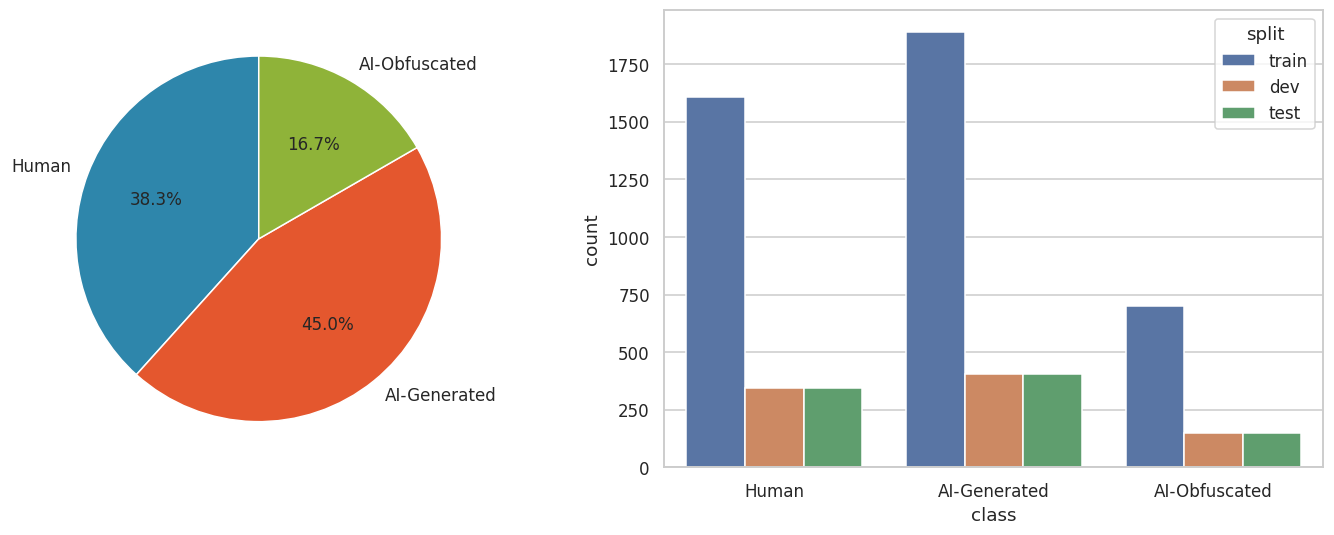

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = [PALETTE[n] for n in CLASS_ORDER]

axes[0].pie(counts.values, labels=CLASS_ORDER, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white'})
# axes[0].set_title('Overall class distribution')

sns.countplot(data=df, x='label_name', hue='split', order=CLASS_ORDER, ax=axes[1])
# axes[1].set_title('Class counts by split')
axes[1].set_xlabel('class')
axes[1].set_ylabel('count')

fig.tight_layout()
save_fig(fig, 'class_distribution')
plt.show()


## 3. Text statistics & feature engineering

We engineer a set of interpretable, language-agnostic linguistic features. Because Kazakh is agglutinative and
Cyrillic-script, we tokenise by lower-casing, mapping punctuation and digits to spaces, then splitting on
whitespace (this avoids English-specific regex assumptions). Sentence counts use terminal punctuation
(`. ! ? ...`). For each text we compute: character count, word count, sentence count, average word length,
unique-word (type) count, lexical diversity (type-token ratio), punctuation count/ratio, digit count/ratio,
uppercase ratio, emoji count, stopword count/ratio, and a count of unusual (non-Cyrillic/Latin) characters.


In [9]:
# A compact, curated Kazakh stopword list (function words, particles, conjunctions, pronouns).
KAZAKH_STOPWORDS = {
    'және', 'мен', 'бен', 'пен', 'бұл', 'ол', 'да', 'де', 'та', 'те', 'бір', 'үшін', 'деп', 'ғана',
    'сол', 'осы', 'ма', 'ме', 'ба', 'бе', 'па', 'пе', 'не', 'өз', 'ал', 'әрі', 'яғни', 'сияқты',
    'туралы', 'кейін', 'дейін', 'арқылы', 'бойынша', 'ретінде', 'қана', 'барлық', 'көп', 'аз',
    'сондай', 'мұндай', 'қандай', 'қай', 'кім', 'неге', 'себебі', 'өйткені', 'бірақ', 'дегенмен',
    'сонымен', 'сондықтан', 'әрбір', 'әр', 'кейбір', 'біз', 'сіз', 'сен', 'олар', 'оның',
    'менің', 'сенің', 'біздің', 'сіздің', 'олардың', 'соң', 'қарай',
}

# Precompute a translation table: punctuation + digits -> space (fast, backslash-free tokenisation).
_EXTRA_PUNCT = '«»—–…„“”’‘·•'
_ALL_PUNCT = string.punctuation + _EXTRA_PUNCT
_TRANS = {ord(c): ' ' for c in _ALL_PUNCT}
for _dch in '0123456789':
    _TRANS[ord(_dch)] = ' '

def tokenize(text: str) -> list[str]:
    # Lower-case, drop punctuation/digits, split on whitespace.
    return text.lower().translate(_TRANS).split()

def count_sentences(text: str) -> int:
    parts = [p for p in re.split(r'[.!?…]+', text) if p.strip()]
    return max(1, len(parts))

_PUNCT_SET = set(_ALL_PUNCT)

def count_punct(text: str) -> int:
    return sum(1 for c in text if c in _PUNCT_SET)

def count_digit(text: str) -> int:
    return sum(1 for c in text if c.isdigit())

def upper_ratio(text: str) -> float:
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return 0.0
    return sum(1 for c in letters if c.isupper()) / len(letters)

def count_emoji(text: str) -> int:
    total = 0
    for ch in text:
        o = ord(ch)
        if (0x1F300 <= o <= 0x1FAFF) or (0x2600 <= o <= 0x27BF) or (0x1F000 <= o <= 0x1F0FF):
            total += 1
    return total

def count_unusual_unicode(text: str) -> int:
    # Characters that are neither Cyrillic, Latin, whitespace, punctuation, numeric, nor symbols.
    total = 0
    for ch in text:
        if ch.isspace():
            continue
        o = ord(ch)
        if 0x0400 <= o <= 0x04FF:
            continue
        if (0x41 <= o <= 0x5A) or (0x61 <= o <= 0x7A):
            continue
        cat = unicodedata.category(ch)
        if cat[0] in ('P', 'N', 'S', 'Z'):
            continue
        total += 1
    return total

def compute_features(frame: pd.DataFrame) -> tuple[pd.DataFrame, list[list[str]]]:
    # Modular feature engineering over the text column; returns features + token lists.
    texts = frame['text'].astype(str).tolist()
    tokens = [tokenize(t) for t in tqdm(texts, desc='tokenising')]
    feats = pd.DataFrame(index=frame.index)
    feats['char_count'] = [len(t) for t in texts]
    feats['word_count'] = [len(tk) for tk in tokens]
    feats['unique_words'] = [len(set(tk)) for tk in tokens]
    feats['sent_count'] = [count_sentences(t) for t in texts]
    feats['avg_word_len'] = [float(np.mean([len(w) for w in tk])) if tk else 0.0 for tk in tokens]
    wc = feats['word_count'].replace(0, np.nan)
    cc = feats['char_count'].replace(0, np.nan)
    feats['lexical_diversity'] = feats['unique_words'] / wc
    feats['words_per_sent'] = feats['word_count'] / feats['sent_count']
    feats['punct_count'] = [count_punct(t) for t in texts]
    feats['punct_ratio'] = feats['punct_count'] / cc
    feats['digit_count'] = [count_digit(t) for t in texts]
    feats['digit_ratio'] = feats['digit_count'] / cc
    feats['upper_ratio'] = [upper_ratio(t) for t in texts]
    feats['emoji_count'] = [count_emoji(t) for t in texts]
    feats['stopword_count'] = [sum(1 for w in tk if w in KAZAKH_STOPWORDS) for tk in tokens]
    feats['stopword_ratio'] = feats['stopword_count'] / wc
    feats['unusual_unicode'] = [count_unusual_unicode(t) for t in texts]
    return feats.fillna(0.0), tokens

feat_df, tokens_list = compute_features(df)
df = pd.concat([df, feat_df], axis=1)
df['tokens'] = tokens_list

NUMERIC_FEATURES = [
    'char_count', 'word_count', 'sent_count', 'avg_word_len', 'unique_words', 'lexical_diversity',
    'words_per_sent', 'punct_count', 'punct_ratio', 'digit_count', 'digit_ratio', 'upper_ratio',
    'emoji_count', 'stopword_count', 'stopword_ratio', 'unusual_unicode',
]

desc = df[NUMERIC_FEATURES].describe().T
save_table(desc, '03_feature_summary')
desc


tokenising:   0%|          | 0/5998 [00:00<?, ?it/s]

[saved table] eda_outputs/tables/03_feature_summary.csv


,count,mean,std,min,25%,50%,75%,max
char_count,5998.0,652.960987,588.943146,78.000000,309.000000,384.000000,670.000000,2761.000000
word_count,5998.0,81.117206,76.904312,9.000000,37.000000,46.000000,81.000000,377.000000
sent_count,5998.0,6.349116,7.659035,1.000000,3.000000,3.000000,5.000000,82.000000
avg_word_len,5998.0,7.043876,0.667256,4.567050,6.571429,7.062500,7.500000,9.576923
unique_words,5998.0,65.611204,50.727792,9.000000,35.000000,42.000000,72.000000,286.000000
lexical_diversity,5998.0,0.890765,0.104248,0.125828,0.851064,0.918605,0.958333,1.000000
words_per_sent,5998.0,14.503847,4.405005,3.222222,11.666667,13.750000,16.528846,54.000000
punct_count,5998.0,16.985495,22.252825,1.000000,6.000000,9.000000,17.000000,454.000000
punct_ratio,5998.0,0.023722,0.009684,0.004484,0.017544,0.022284,0.028646,0.190972
digit_count,5998.0,2.004168,10.947971,0.000000,0.000000,0.000000,0.000000,263.000000


[saved figure] eda_outputs/figures/03_feature_histograms.png


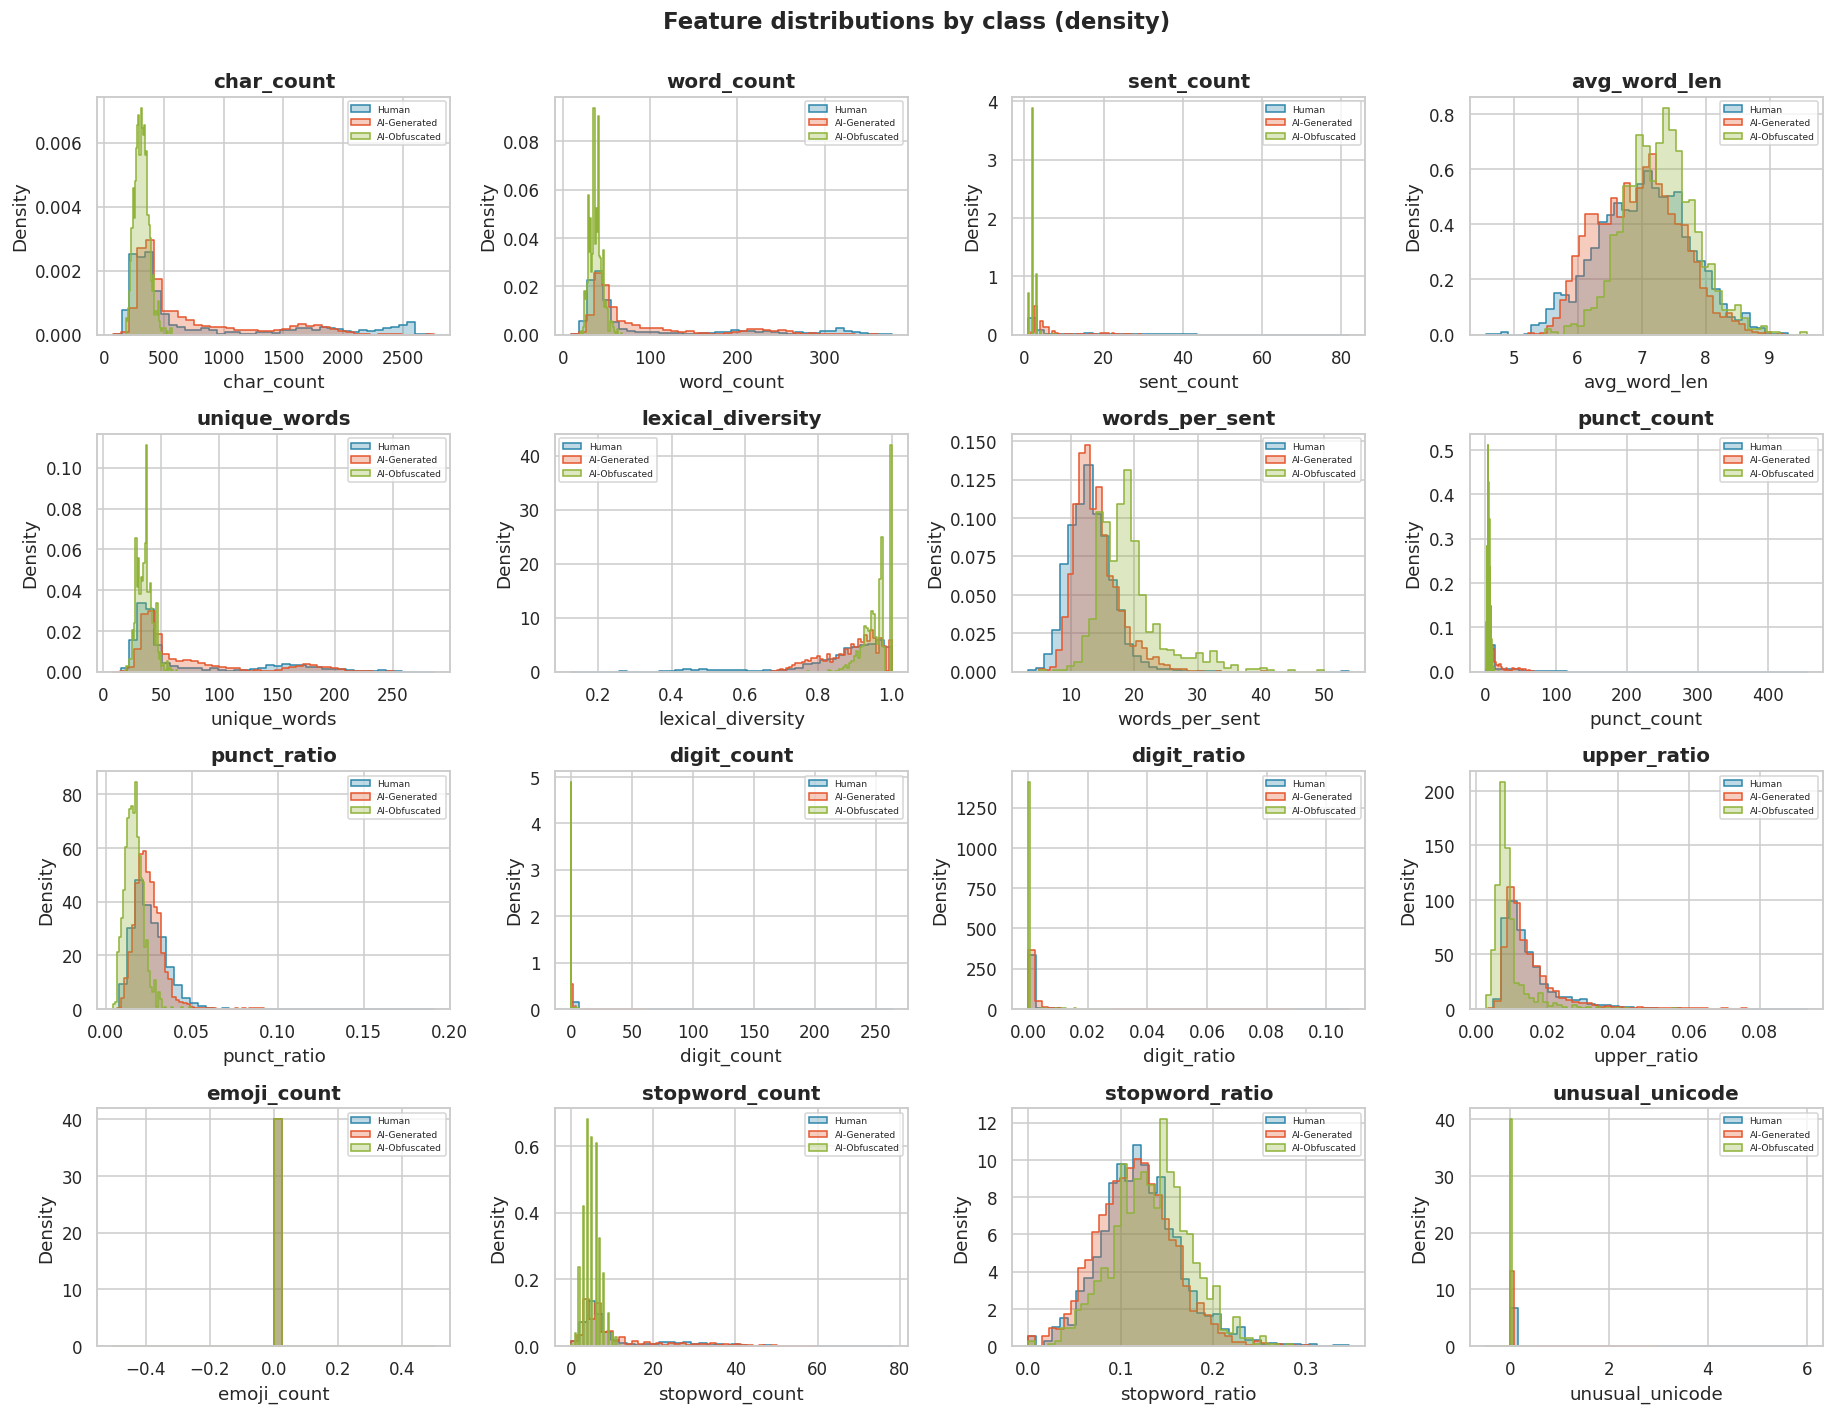

In [10]:
def feature_grid(frame: pd.DataFrame, features: list[str], kind: str, fname: str, title: str) -> None:
    # Draw a grid of per-feature plots: histogram (by class), boxplot, or violin.
    ncols = 4
    nrows = math.ceil(len(features) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, feat in enumerate(features):
        ax = axes[i]
        if kind == 'hist':
            for name in CLASS_ORDER:
                sub = frame.loc[frame['label_name'] == name, feat]
                sns.histplot(sub, ax=ax, color=PALETTE[name], label=name, stat='density',
                             bins=40, element='step', fill=True, alpha=0.30)
            ax.legend(fontsize=6)
        elif kind == 'box':
            sns.boxplot(data=frame, x='label_name', y=feat, order=CLASS_ORDER, palette=PALETTE,
                        ax=ax, showfliers=False)
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelrotation=20)
        elif kind == 'violin':
            sns.violinplot(data=frame, x='label_name', y=feat, order=CLASS_ORDER, palette=PALETTE,
                           ax=ax, cut=0)
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelrotation=20)
        ax.set_title(feat)
    for j in range(len(features), len(axes)):
        axes[j].axis('off')
    fig.suptitle(title, y=1.002, fontsize=15, fontweight='bold')
    fig.tight_layout()
    save_fig(fig, fname)
    plt.show()

feature_grid(df, NUMERIC_FEATURES, 'hist', 'feature_histograms', 'Feature distributions by class (density)')


[saved figure] eda_outputs/figures/03_feature_boxplots.png


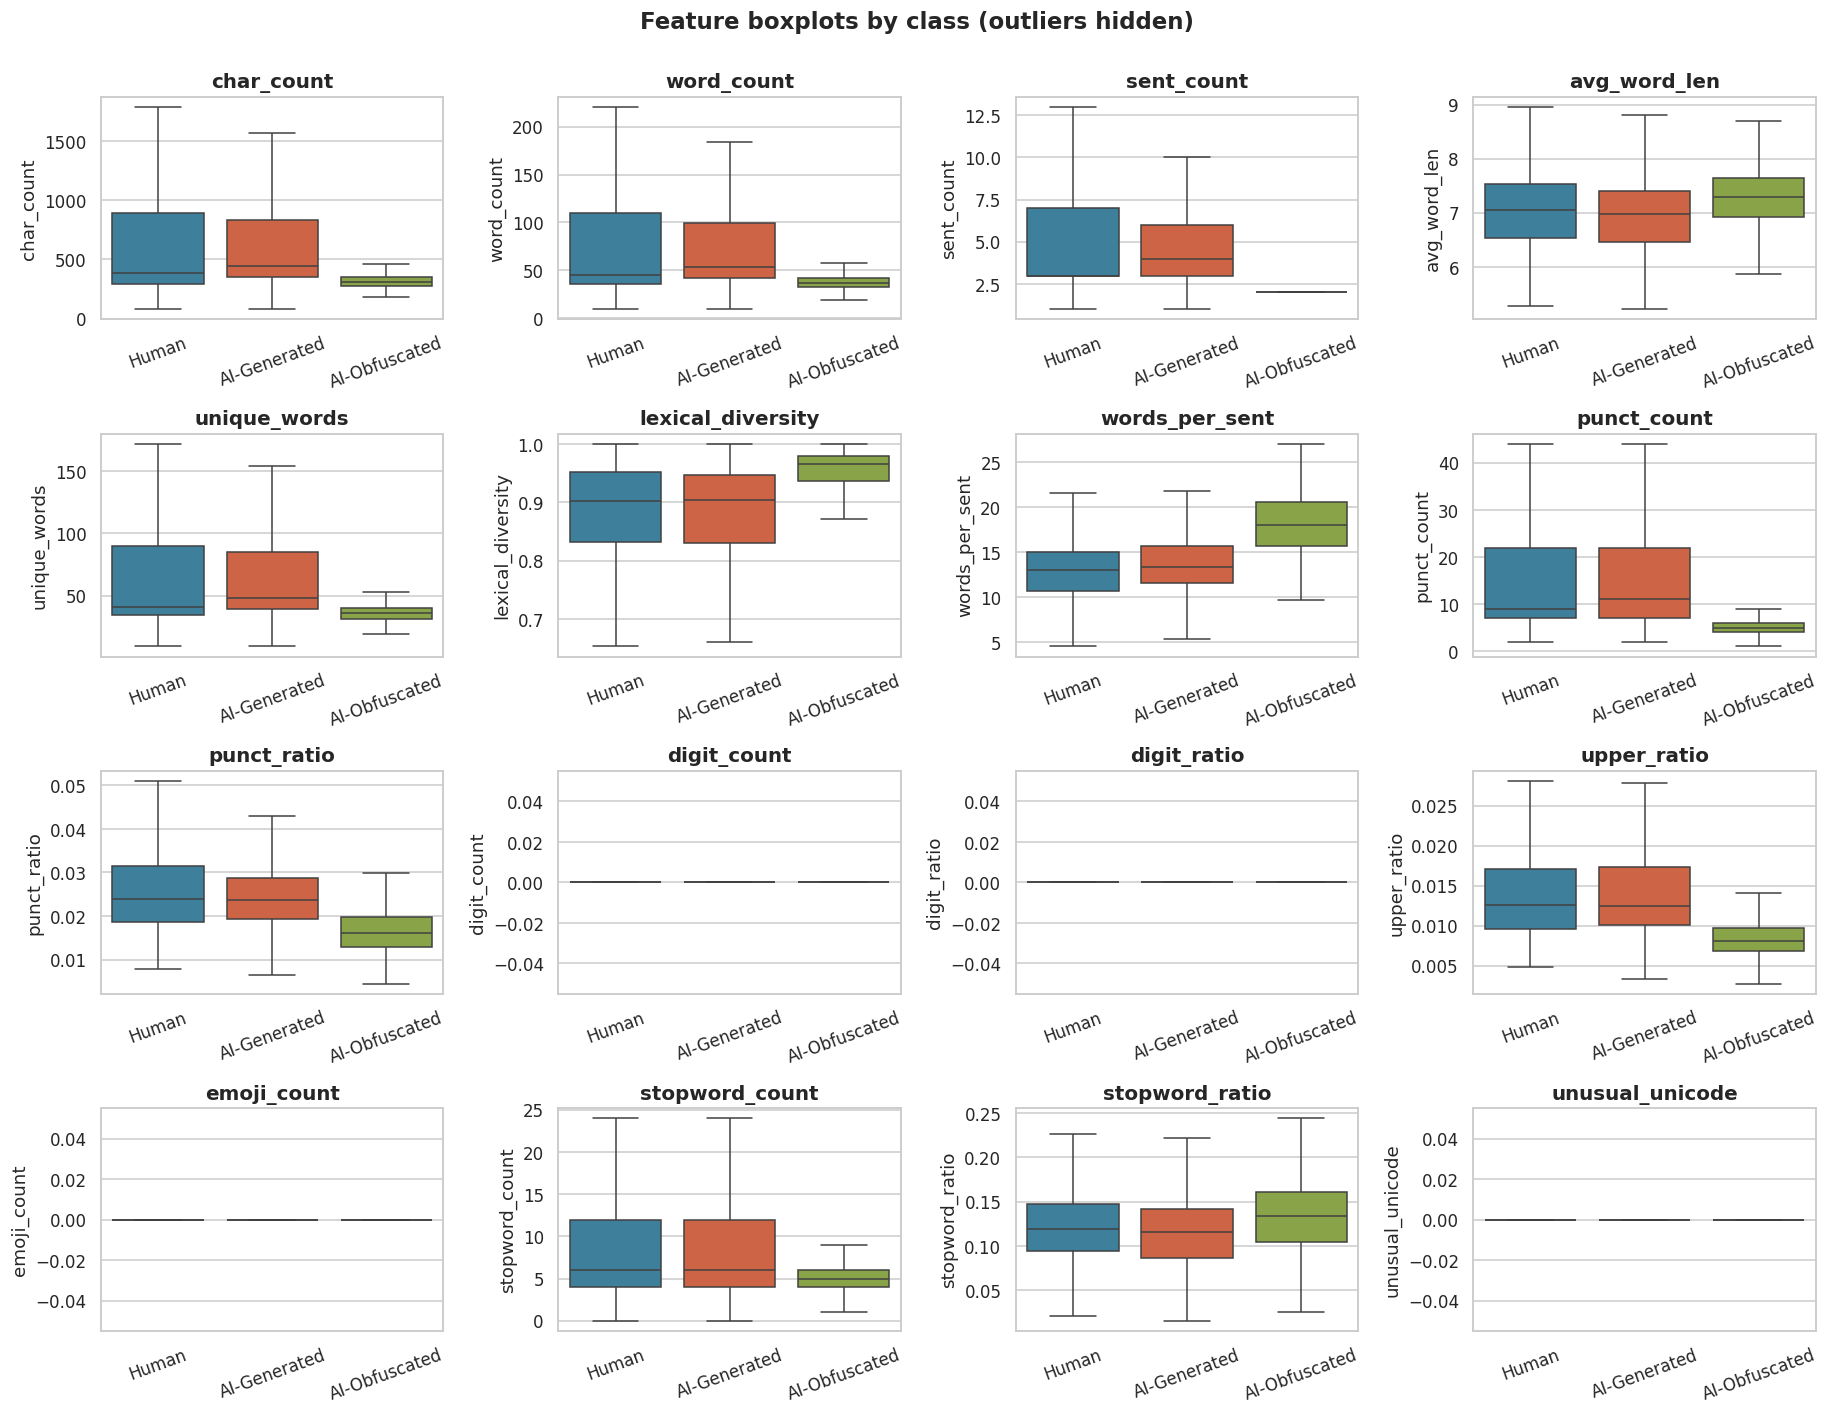

[saved figure] eda_outputs/figures/04_feature_violins.png


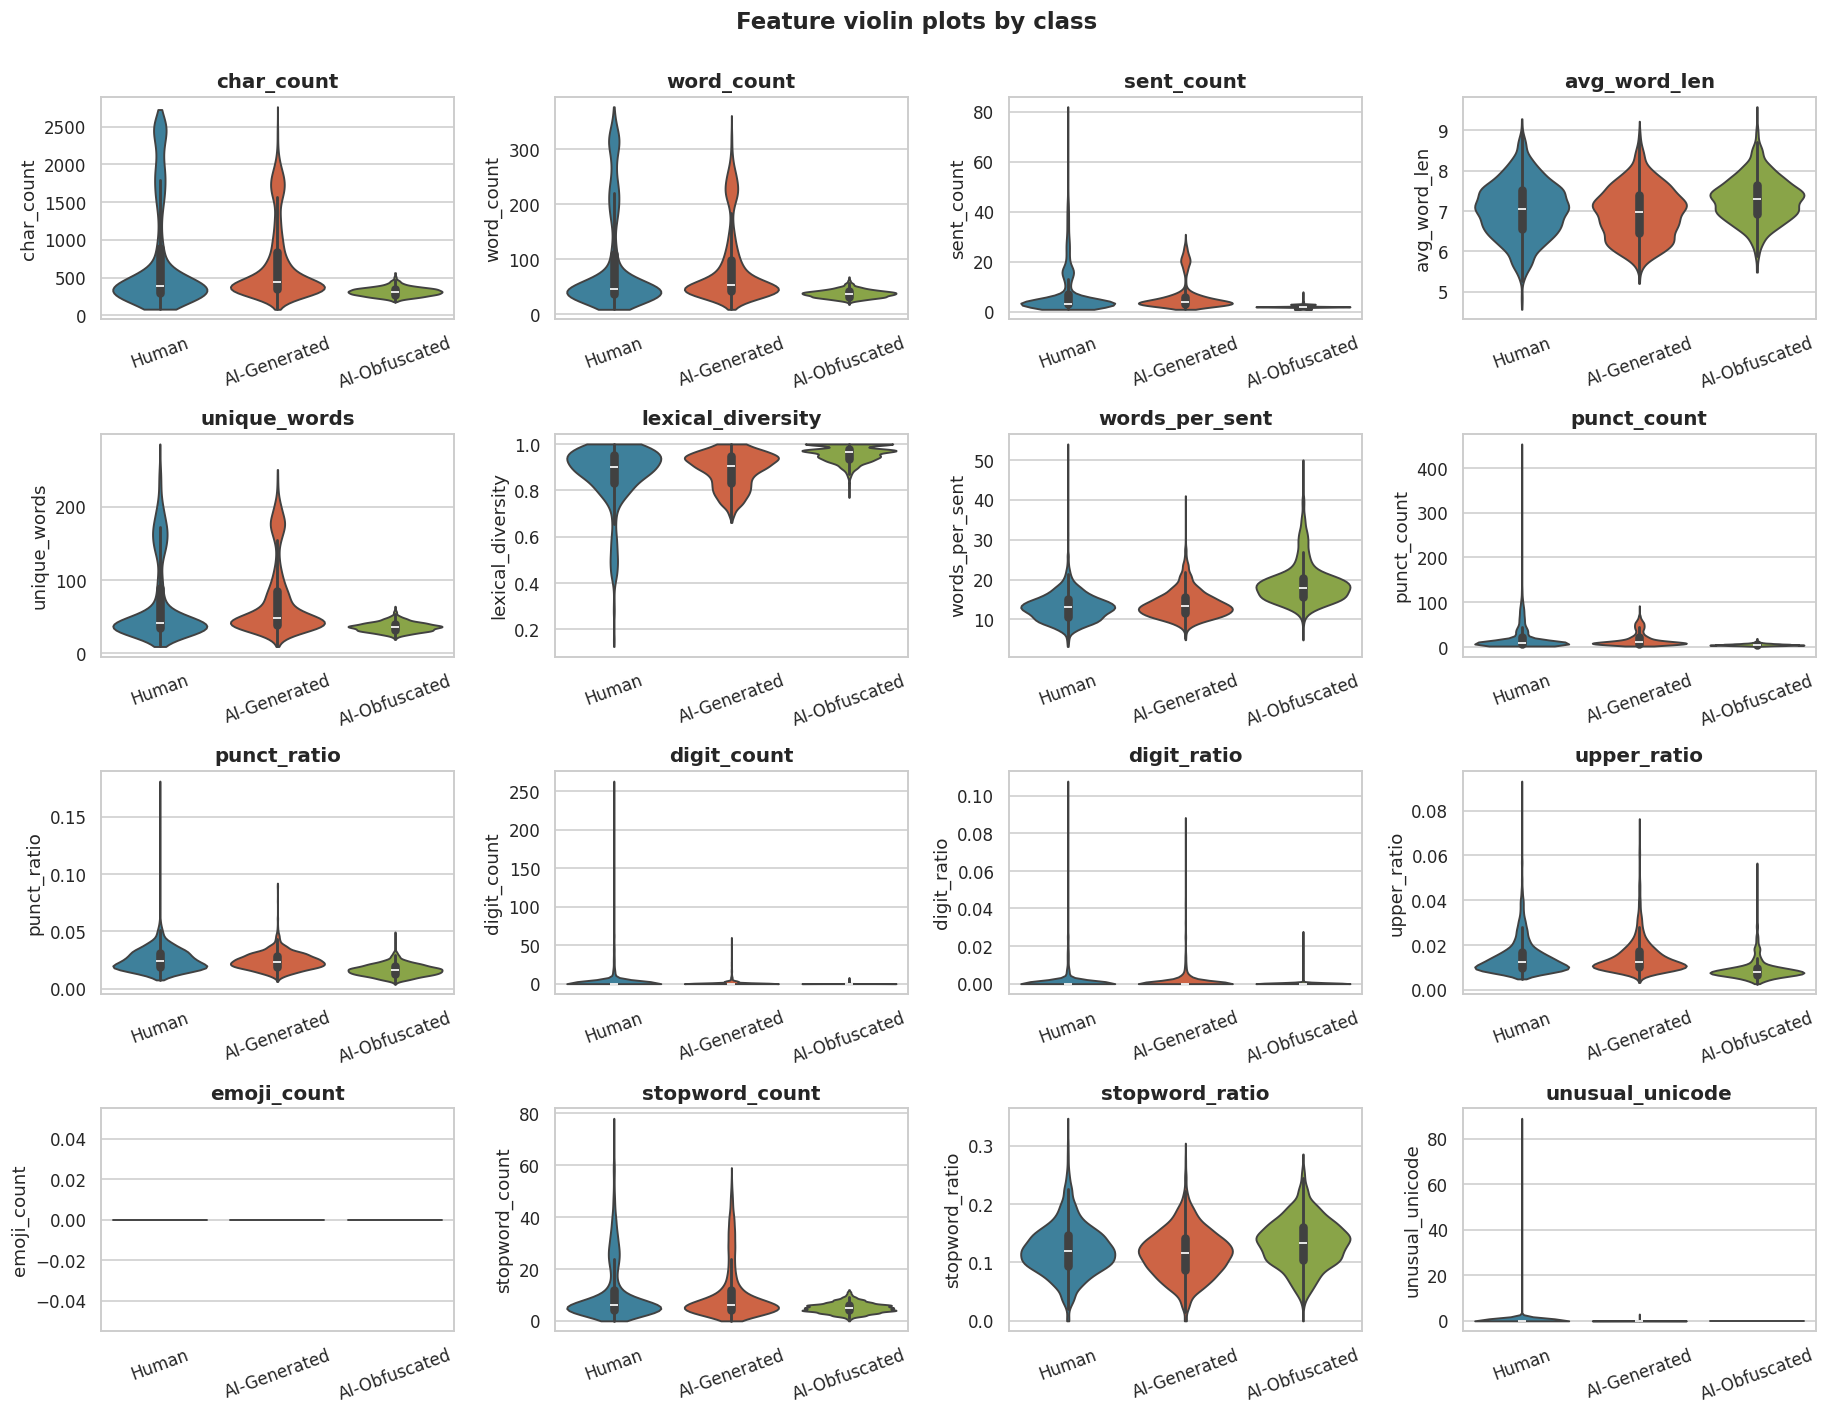

In [ ]:
feature_grid(df, NUMERIC_FEATURES, 'box', 'feature_boxplots', 'Feature boxplots by class (outliers hidden)')
feature_grid(df, NUMERIC_FEATURES, 'violin', 'feature_violins', 'Feature violin plots by class')


## 4. Length analysis

Text length is one of the strongest and most easily-gamed signals in AI-text detection, so we examine it in
detail. We compare word- and character-length across the three classes using KDE, violin, box, and ECDF plots.
The ECDF is especially useful for spotting hard length thresholds or truncation artefacts introduced during
dataset construction.


[saved figure] eda_outputs/figures/17_length_word_count.png


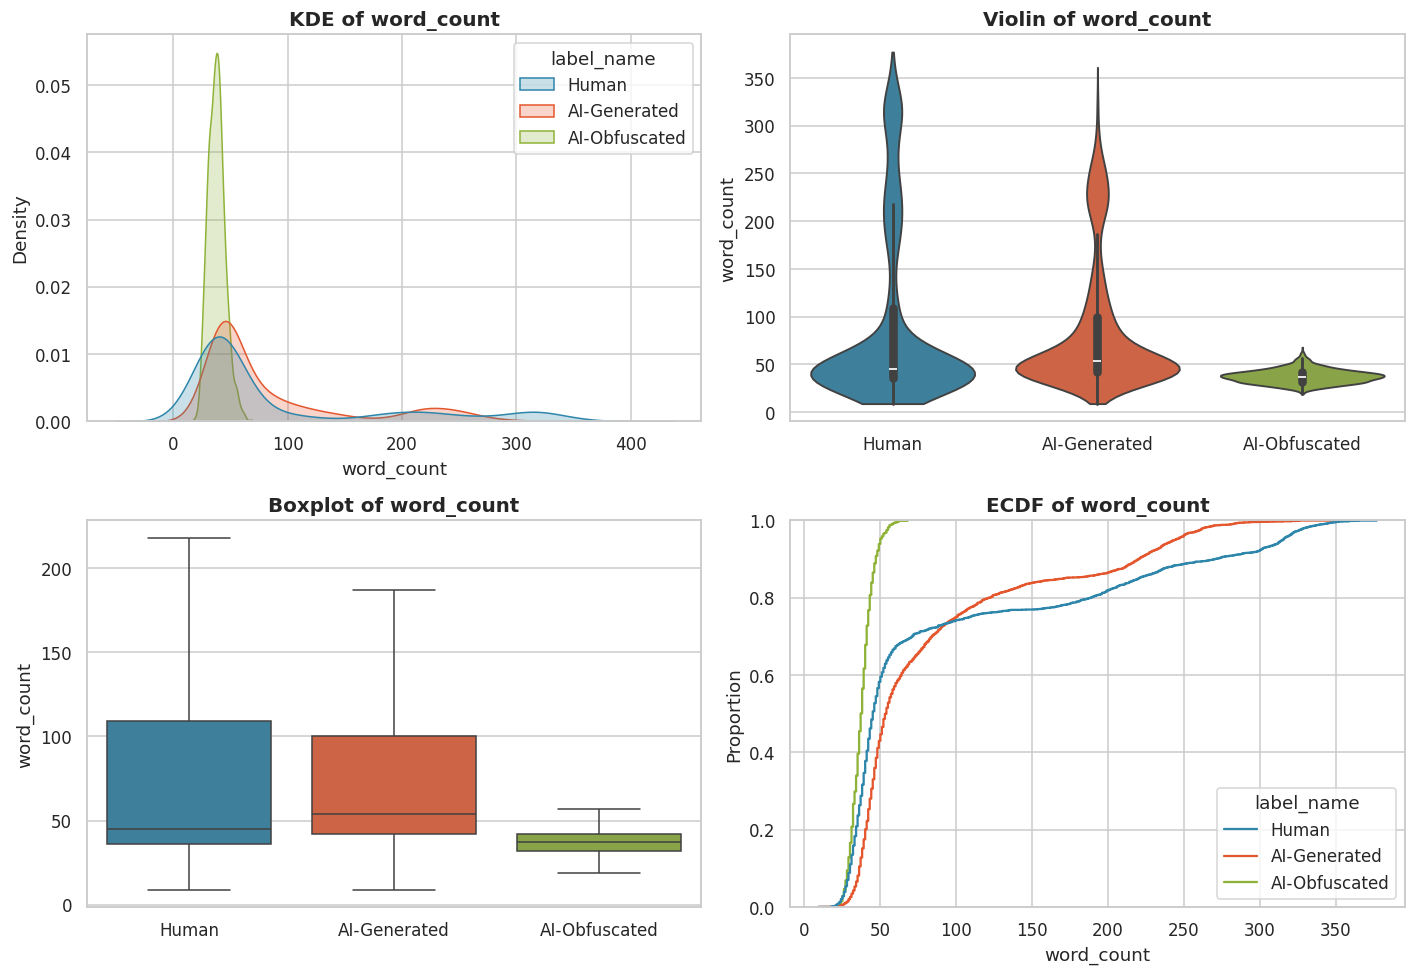

[saved figure] eda_outputs/figures/18_length_char_count.png


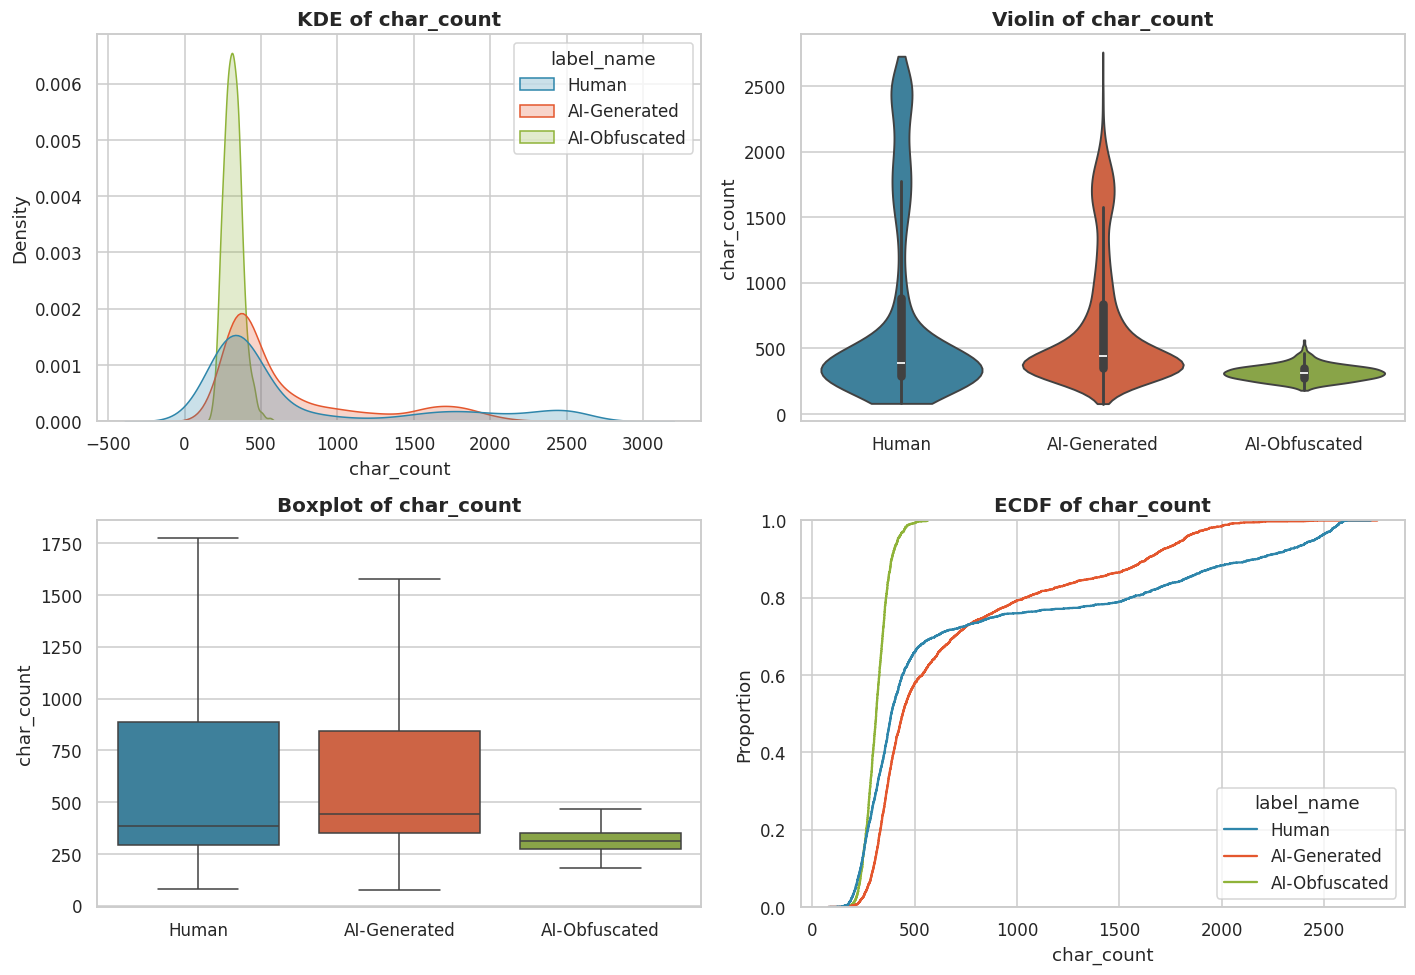

In [27]:
def length_panel(frame: pd.DataFrame, col: str, fname: str) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    sns.kdeplot(data=frame, x=col, hue='label_name', hue_order=CLASS_ORDER, palette=PALETTE,
                common_norm=False, fill=True, alpha=0.25, ax=axes[0, 0])
    axes[0, 0].set_title(f'KDE of {col}')
    sns.violinplot(data=frame, x='label_name', y=col, order=CLASS_ORDER, palette=PALETTE,
                   cut=0, ax=axes[0, 1])
    axes[0, 1].set_title(f'Violin of {col}')
    axes[0, 1].set_xlabel('')
    sns.boxplot(data=frame, x='label_name', y=col, order=CLASS_ORDER, palette=PALETTE,
                showfliers=False, ax=axes[1, 0])
    axes[1, 0].set_title(f'Boxplot of {col}')
    axes[1, 0].set_xlabel('')
    sns.ecdfplot(data=frame, x=col, hue='label_name', hue_order=CLASS_ORDER, palette=PALETTE,
                 ax=axes[1, 1])
    axes[1, 1].set_title(f'ECDF of {col}')
    # fig.suptitle(f'Length analysis: {col}', y=1.002, fontsize=15, fontweight='bold')
    fig.tight_layout()
    save_fig(fig, fname)
    plt.show()

length_panel(df, 'word_count', 'length_word_count')
length_panel(df, 'char_count', 'length_char_count')


## 5. Vocabulary analysis

We analyse the lexicon overall and per class: the most frequent words, the fraction of rare (hapax) words,
class-specific frequent words, stopword usage, and the most common bigrams and trigrams. We also build word
clouds per class and extract TF-IDF keywords that best characterise each class. N-gram extraction uses our
custom Kazakh-aware tokeniser (via scikit-learn `analyzer` callables) to avoid English regex assumptions.


Total tokens        : 486,541
Vocabulary size     : 43,109
Hapax (freq==1)     : 17,032 (39.5% of vocab)

Most frequent stopwords:
stopword  count
    және   9987
     бұл   6089
     мен   5688
      ол   3169
    үшін   2877
    оның   2512
     бір   2010
  арқылы   1666
 олардың   1590
      да   1579
      де   1236
   бірақ   1201
    олар   1176
     деп   1132
     осы   1119
     пен   1051
      өз    966
  сияқты    948
  туралы    764
  сондай    730
[saved table] eda_outputs/tables/05_top_words_overall.csv
[saved figure] eda_outputs/figures/13_top_words_per_class.png


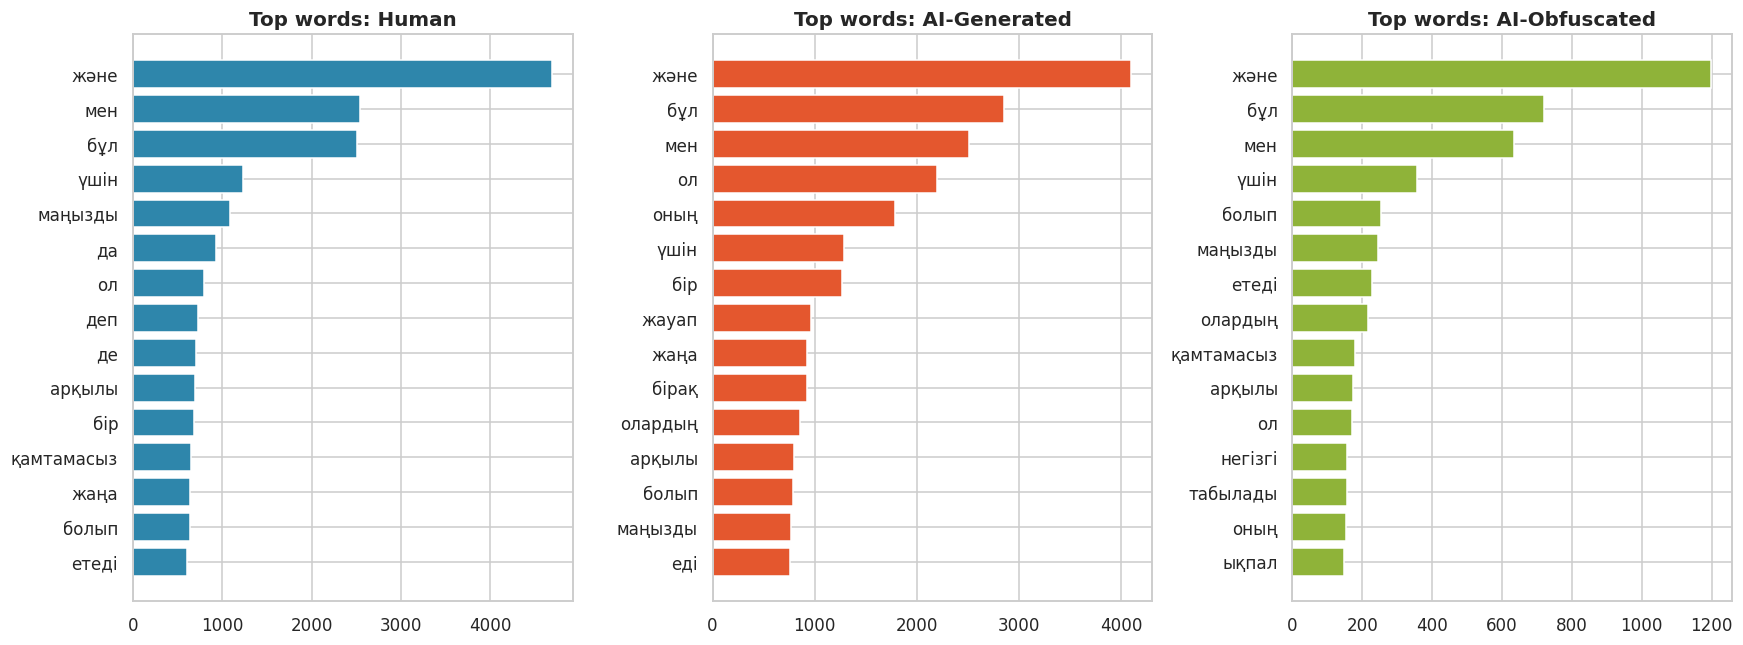

In [24]:
# Overall + per-class frequency counters.
all_tokens = [w for tk in df['tokens'] for w in tk]
global_counter = Counter(all_tokens)
vocab_size = len(global_counter)
hapax = [w for w, c in global_counter.items() if c == 1]

print(f'Total tokens        : {len(all_tokens):,}')
print(f'Vocabulary size     : {vocab_size:,}')
print(f'Hapax (freq==1)     : {len(hapax):,} ({100*len(hapax)/max(1,vocab_size):.1f}% of vocab)')

class_counters = {name: Counter(w for tk in df.loc[df['label_name'] == name, 'tokens'] for w in tk)
                  for name in CLASS_ORDER}

# Stopword usage overall.
sw_present = {w: global_counter[w] for w in KAZAKH_STOPWORDS if w in global_counter}
sw_top = pd.DataFrame(sorted(sw_present.items(), key=lambda x: -x[1])[:20], columns=['stopword', 'count'])
print('\nMost frequent stopwords:')
print(sw_top.to_string(index=False))

# Top overall words + per-class top words.
top_overall = pd.DataFrame(global_counter.most_common(25), columns=['word', 'count'])
save_table(top_overall.set_index('word'), '05_top_words_overall')

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, name in zip(axes, CLASS_ORDER):
    top = class_counters[name].most_common(15)
    words = [w for w, _ in top][::-1]
    vals = [c for _, c in top][::-1]
    ax.barh(words, vals, color=PALETTE[name])
    ax.set_title(f'Top words: {name}')
# fig.suptitle('Most frequent words per class', y=1.01, fontsize=15, fontweight='bold')
fig.tight_layout()
save_fig(fig, 'top_words_per_class')
plt.show()


[saved table] eda_outputs/tables/05_top_bigrams.csv
[saved table] eda_outputs/tables/05_top_trigrams.csv
[saved figure] eda_outputs/figures/12_top_ngrams.png


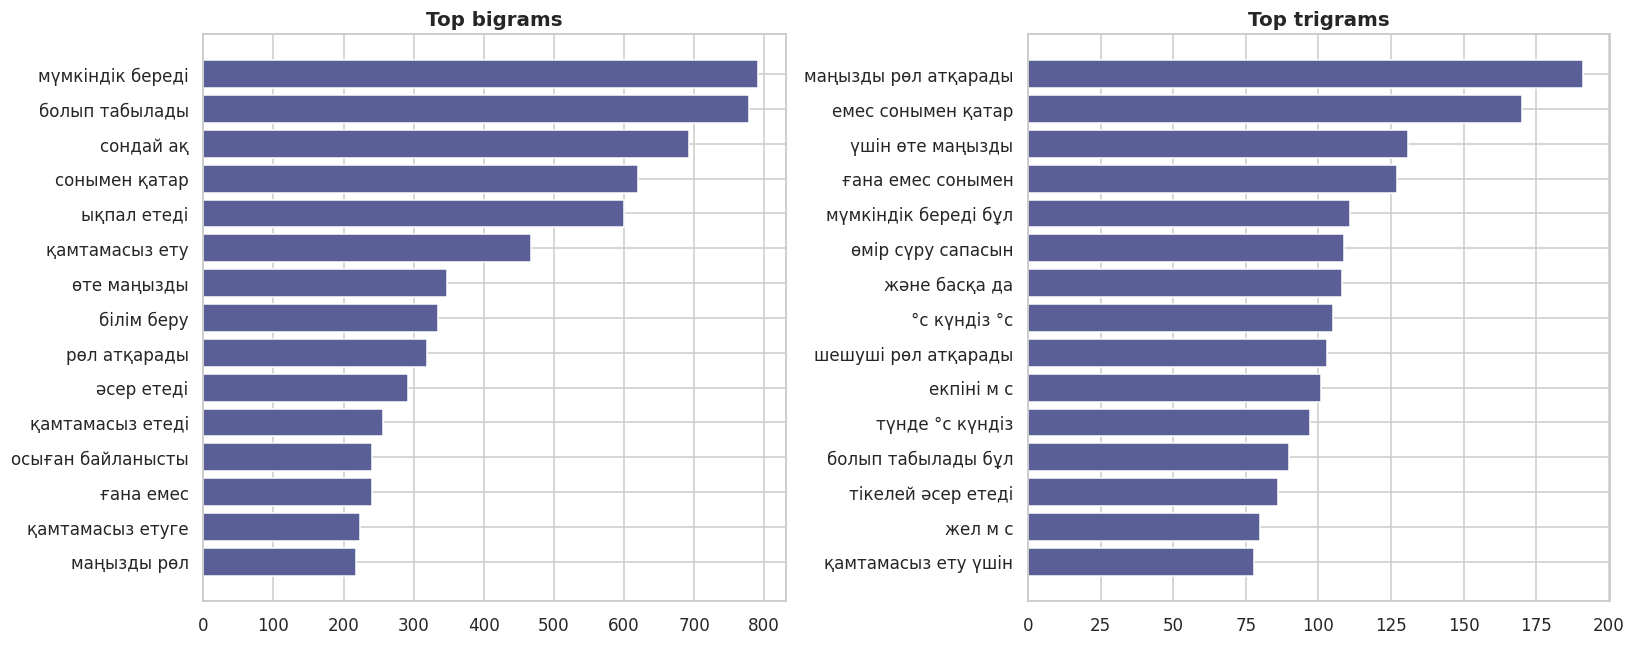

In [23]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

def make_ngram_analyzer(n: int) -> Callable[[str], list[str]]:
    # Build an n-gram analyzer on top of the Kazakh-aware tokeniser.
    def analyzer(doc: str) -> list[str]:
        toks = tokenize(doc)
        if n == 1:
            return toks
        return [' '.join(toks[i:i + n]) for i in range(len(toks) - n + 1)]
    return analyzer

def top_ngrams(texts: list[str], n: int, k: int = 15) -> pd.DataFrame:
    vec = CountVectorizer(analyzer=make_ngram_analyzer(n), min_df=5)
    X = vec.fit_transform(texts)
    sums = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    order = np.argsort(sums)[::-1][:k]
    return pd.DataFrame({'ngram': vocab[order], 'count': sums[order]})

texts_all = df['text'].tolist()
bigrams = top_ngrams(texts_all, 2, 15)
trigrams = top_ngrams(texts_all, 3, 15)
save_table(bigrams.set_index('ngram'), '05_top_bigrams')
save_table(trigrams.set_index('ngram'), '05_top_trigrams')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, data, title in zip(axes, [bigrams, trigrams], ['Top bigrams', 'Top trigrams']):
    d = data.iloc[::-1]
    ax.barh(d['ngram'], d['count'], color='#5B5F97')
    ax.set_title(title)
# fig.suptitle('Most frequent n-grams (whole corpus)', y=1.01, fontsize=15, fontweight='bold')
fig.tight_layout()
save_fig(fig, 'top_ngrams')
plt.show()


[saved figure] eda_outputs/figures/08_wordclouds.png


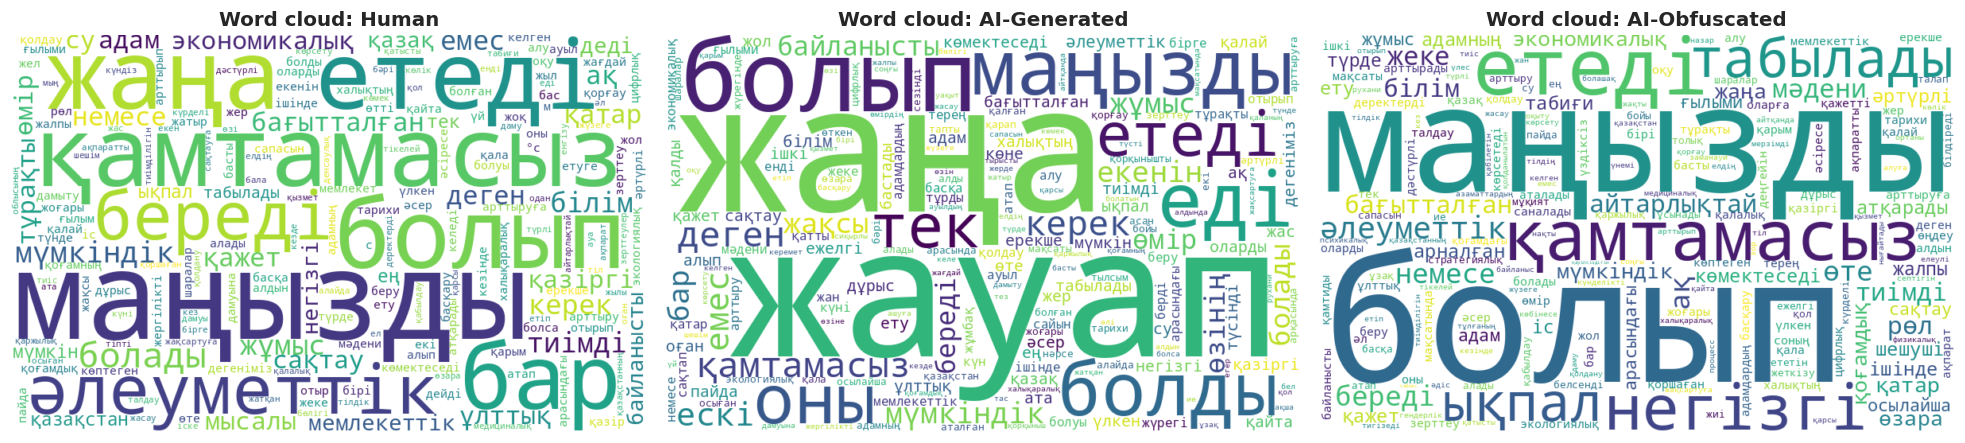

In [14]:
# Word clouds per class (optional dependency: wordcloud).
try:
    from wordcloud import WordCloud
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, name in zip(axes, CLASS_ORDER):
        freqs = {w: c for w, c in class_counters[name].items() if w not in KAZAKH_STOPWORDS}
        wc = WordCloud(width=800, height=500, background_color='white',
                       colormap='viridis', prefer_horizontal=0.95).generate_from_frequencies(freqs)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'Word cloud: {name}', fontweight='bold')
    fig.tight_layout()
    save_fig(fig, 'wordclouds')
    plt.show()
except Exception as e:
    print('wordcloud not available or failed:', e)
    print('Install with: pip install wordcloud')


In [15]:
# TF-IDF keywords that best characterise each class (mean TF-IDF within class).
tfidf = TfidfVectorizer(analyzer=tokenize, min_df=5, sublinear_tf=True)
Xtf = tfidf.fit_transform(texts_all)
terms = np.array(tfidf.get_feature_names_out())

rows = []
for name in CLASS_ORDER:
    mask = (df['label_name'] == name).values
    mean_tfidf = np.asarray(Xtf[mask].mean(axis=0)).ravel()
    top_idx = np.argsort(mean_tfidf)[::-1][:15]
    rows.append(pd.Series(terms[top_idx], name=name).reset_index(drop=True))

tfidf_keywords = pd.concat(rows, axis=1)
tfidf_keywords.index = [f'kw_{i+1}' for i in range(len(tfidf_keywords))]
save_table(tfidf_keywords, '05_tfidf_keywords_per_class')
tfidf_keywords


[saved table] eda_outputs/tables/05_tfidf_keywords_per_class.csv


,Human,AI-Generated,AI-Obfuscated
kw_1,және,және,және
kw_2,бұл,мен,бұл
kw_3,мен,бұл,мен
kw_4,маңызды,үшін,үшін
kw_5,үшін,ол,болып
kw_6,қамтамасыз,оның,етеді
kw_7,арқылы,жауап,олардың
kw_8,да,бір,маңызды
kw_9,етеді,жаңа,негізгі
kw_10,тиімді,жақсы,табылады


## 6. Language quality checks

Before modelling we audit data quality. We flag empty texts, exact duplicate texts, near-duplicates (identical
after removing case, spacing and punctuation but not byte-identical), texts that are only punctuation or only
numbers, extremely short and extremely long texts, potential encoding problems (Unicode replacement character),
and texts containing unusual (non-Cyrillic/Latin) characters. All findings are summarised in one table.


In [16]:
REPLACEMENT_CHAR = chr(0xFFFD)

def is_only_punct(text: str) -> bool:
    s = text.strip()
    return len(s) > 0 and not any(c.isalnum() for c in s)

def is_only_numbers(text: str) -> bool:
    s = text.strip()
    if not s or not any(c.isdigit() for c in s):
        return False
    return all(c.isdigit() or c.isspace() or c in _PUNCT_SET for c in s)

def normalize_text(text: str) -> str:
    return ''.join(ch for ch in text.lower() if ch.isalnum())

norm = df['text'].map(normalize_text)
exact_dup = df['text'].duplicated(keep=False)
norm_dup = norm.duplicated(keep=False)
near_dup = norm_dup & (~exact_dup)

short_thresh = 5           # words
long_thresh = df['char_count'].quantile(0.99)

flags = pd.DataFrame(index=df.index)
flags['empty'] = df['text'].str.strip().eq('')
flags['exact_duplicate'] = exact_dup
flags['near_duplicate'] = near_dup
flags['only_punctuation'] = df['text'].map(is_only_punct)
flags['only_numbers'] = df['text'].map(is_only_numbers)
flags['very_short'] = df['word_count'] < short_thresh
flags['very_long'] = df['char_count'] > long_thresh
flags['encoding_issue'] = df['text'].str.contains(REPLACEMENT_CHAR, regex=False)
flags['unusual_unicode'] = df['unusual_unicode'] > 0

summary = pd.DataFrame({
    'count': flags.sum().astype(int),
    'percent': (flags.mean() * 100).round(3),
})
print(f'Long-text threshold (99th pct chars): {long_thresh:.0f}')
save_table(summary, '06_quality_checks')
summary


Long-text threshold (99th pct chars): 2537
[saved table] eda_outputs/tables/06_quality_checks.csv


,count,percent
empty,0,0.000
exact_duplicate,0,0.000
near_duplicate,0,0.000
only_punctuation,0,0.000
only_numbers,0,0.000
very_short,0,0.000
very_long,58,0.967
encoding_issue,0,0.000
unusual_unicode,7,0.117


In [17]:
# Quality flags broken down by class (leakage of duplicates across classes is a red flag).
flags_by_class = flags.copy()
flags_by_class['label_name'] = df['label_name'].values
by_class = flags_by_class.groupby('label_name').mean(numeric_only=True).mul(100).round(2).reindex(CLASS_ORDER)
save_table(by_class, '06_quality_by_class')
print('Percent of each flag by class:')
print(by_class)

# Do exact-duplicate texts appear under more than one label? (annotation inconsistency check)
dup_texts = df[df['text'].duplicated(keep=False)]
conflict = (dup_texts.groupby('text')['label'].nunique() > 1)
n_conflicting = int(conflict.sum())
print(f'\nDuplicate texts assigned conflicting labels: {n_conflicting}')
if n_conflicting:
    example = conflict[conflict].index[0]
    print('Example conflicting text (truncated):', example[:160])


[saved table] eda_outputs/tables/06_quality_by_class.csv
Percent of each flag by class:
               empty  exact_duplicate  near_duplicate  only_punctuation  \
label_name                                                                
Human            0.0              0.0             0.0               0.0   
AI-Generated     0.0              0.0             0.0               0.0   
AI-Obfuscated    0.0              0.0             0.0               0.0   

               only_numbers  very_short  very_long  encoding_issue  \
label_name                                                           
Human                   0.0         0.0       2.48             0.0   
AI-Generated            0.0         0.0       0.04             0.0   
AI-Obfuscated           0.0         0.0       0.00             0.0   

               unusual_unicode  
label_name                      
Human                     0.26  
AI-Generated              0.04  
AI-Obfuscated             0.00  

Duplicate texts ass

## 7. Class-wise comparison

We consolidate the key statistics per class into a single comparison table: average and median length,
vocabulary richness (lexical diversity), punctuation frequency, digit frequency, and sentence count. A
z-scored heatmap makes the relative differences easy to read at a glance.


[saved table] eda_outputs/tables/07_classwise_comparison.csv
label_name             Human  AI-Generated  AI-Obfuscated
n                  2299.0000     2699.0000      1000.0000
mean_words           93.9295       86.2931        37.6920
median_words         45.0000       54.0000        37.0000
mean_chars          761.4450      685.6921       315.2150
median_chars        386.0000      442.0000       312.0000
lexical_diversity     0.8651        0.8876         0.9584
avg_word_len          7.0372        6.9587         7.2892
punct_ratio           0.0258        0.0246         0.0166
digit_ratio           0.0017        0.0019         0.0003
mean_sentences        7.8686        6.6321         2.0920
stopword_ratio        0.1218        0.1158         0.1336
[saved figure] eda_outputs/figures/09_classwise_zscore_heatmap.png


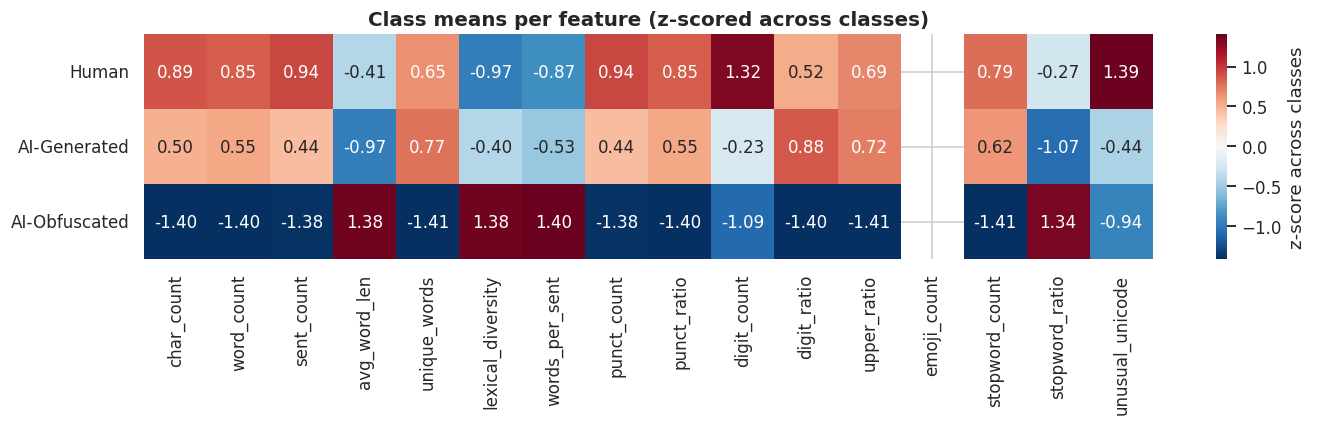

,n,mean_words,median_words,mean_chars,median_chars,lexical_diversity,avg_word_len,punct_ratio,digit_ratio,mean_sentences,stopword_ratio
label_name,,,,,,,,,,,
Human,2299,93.9295,45.0,761.4450,386.0,0.8651,7.0372,0.0258,0.0017,7.8686,0.1218
AI-Generated,2699,86.2931,54.0,685.6921,442.0,0.8876,6.9587,0.0246,0.0019,6.6321,0.1158
AI-Obfuscated,1000,37.6920,37.0,315.2150,312.0,0.9584,7.2892,0.0166,0.0003,2.0920,0.1336


In [18]:
comparison = df.groupby('label_name').agg(
    n=('text', 'size'),
    mean_words=('word_count', 'mean'),
    median_words=('word_count', 'median'),
    mean_chars=('char_count', 'mean'),
    median_chars=('char_count', 'median'),
    lexical_diversity=('lexical_diversity', 'mean'),
    avg_word_len=('avg_word_len', 'mean'),
    punct_ratio=('punct_ratio', 'mean'),
    digit_ratio=('digit_ratio', 'mean'),
    mean_sentences=('sent_count', 'mean'),
    stopword_ratio=('stopword_ratio', 'mean'),
).reindex(CLASS_ORDER).round(4)
save_table(comparison, '07_classwise_comparison')
print(comparison.T)

# Z-scored heatmap of class means across features.
heat = df.groupby('label_name')[NUMERIC_FEATURES].mean().reindex(CLASS_ORDER)
heat_z = (heat - heat.mean()) / heat.std(ddof=0)
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heat_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'z-score across classes'})
ax.set_title('Class means per feature (z-scored across classes)')
ax.set_ylabel('')
fig.tight_layout()
save_fig(fig, 'classwise_zscore_heatmap')
plt.show()
comparison


## 8. Readability

Standard readability indices (Flesch Reading Ease, Flesch-Kincaid, SMOG, Gunning Fog) are calibrated for English
and depend on English syllable dictionaries and word lists. They are **not valid for Kazakh**, an agglutinative
Turkic language written in Cyrillic where a single inflected word carries what English expresses in several
words. Applying them would produce numbers, but not meaningful ones.

Instead we compute **script-agnostic proxies**: the Automated Readability Index (ARI), which uses only
characters/words/sentences and therefore transfers across scripts, plus an approximate syllable count based on
Kazakh vowels (in Turkic languages the number of syllables equals the number of vowels). These are used only for
relative comparison between classes, not as absolute grade levels.


[saved table] eda_outputs/tables/08_readability_proxies.csv
[saved figure] eda_outputs/figures/10_readability_proxies.png


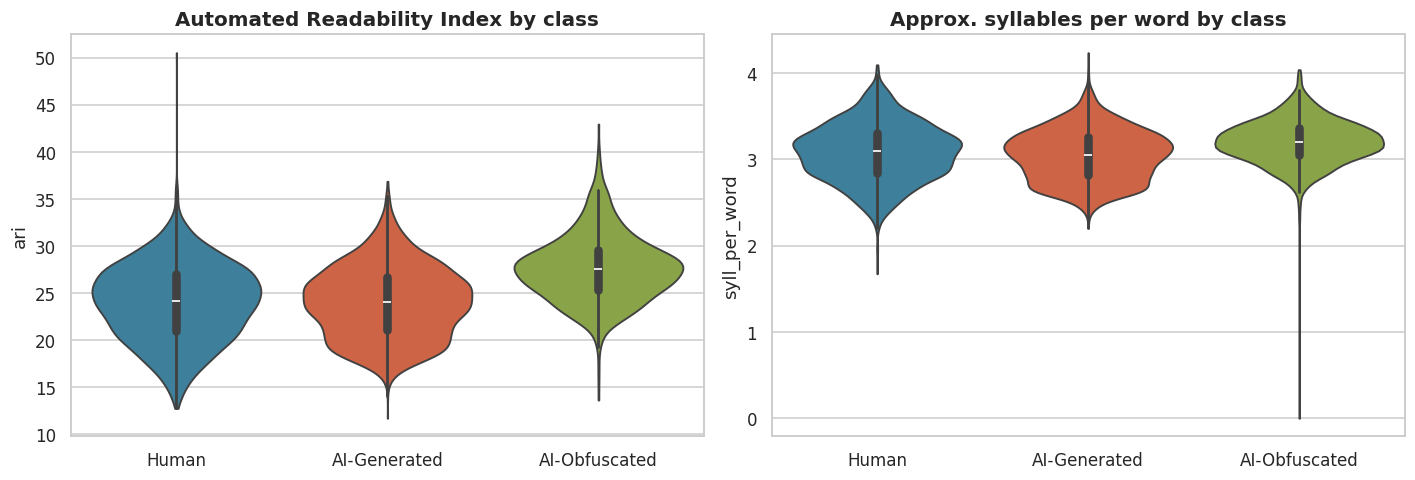

,ari,syllables_per_word,words_per_sentence,chars_per_word
label_name,,,,
Human,23.962,3.083,13.097,7.037
AI-Generated,24.008,3.048,13.983,6.959
AI-Obfuscated,27.667,3.204,19.144,7.289


In [19]:
KAZAKH_VOWELS = set('аәеёиоөуүұыіэюя')

def count_vowels(text: str) -> int:
    return sum(1 for c in text.lower() if c in KAZAKH_VOWELS)

df['syllables_approx'] = df['text'].map(count_vowels)
df['syll_per_word'] = df['syllables_approx'] / df['word_count'].replace(0, np.nan)
# Automated Readability Index (script-agnostic; character-based).
df['ari'] = (4.71 * (df['char_count'] / df['word_count'].replace(0, np.nan))
             + 0.5 * (df['word_count'] / df['sent_count'])
             - 21.43)
df[['syll_per_word', 'ari']] = df[['syll_per_word', 'ari']].fillna(0.0)

readability = df.groupby('label_name').agg(
    ari=('ari', 'mean'),
    syllables_per_word=('syll_per_word', 'mean'),
    words_per_sentence=('words_per_sent', 'mean'),
    chars_per_word=('avg_word_len', 'mean'),
).reindex(CLASS_ORDER).round(3)
save_table(readability, '08_readability_proxies')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.violinplot(data=df, x='label_name', y='ari', order=CLASS_ORDER, palette=PALETTE, cut=0, ax=axes[0])
axes[0].set_title('Automated Readability Index by class')
axes[0].set_xlabel('')
sns.violinplot(data=df, x='label_name', y='syll_per_word', order=CLASS_ORDER, palette=PALETTE, cut=0, ax=axes[1])
axes[1].set_title('Approx. syllables per word by class')
axes[1].set_xlabel('')
fig.tight_layout()
save_fig(fig, 'readability_proxies')
plt.show()
readability


## 9. Token analysis (XLM-RoBERTa)

Transformer classifiers operate on sub-word tokens with a fixed maximum sequence length, so the sub-word token
distribution directly determines how much text is truncated at 128/256/512 tokens. We use the multilingual
`xlm-roberta-base` tokenizer. This step downloads a model and is guarded by `RUN_HEAVY`. When `RUN_HEAVY` is
`False`, we fall back to a rough word-count-based estimate (clearly labelled) so the section still produces a
ballpark, but the real tokenizer should be used for final numbers.


In [20]:
MAX_LENS = [128, 256, 512]
token_source = None

if RUN_HEAVY:
    try:
        from transformers import AutoTokenizer
        tok = AutoTokenizer.from_pretrained('xlm-roberta-base')
        lengths = [len(tok.encode(t, add_special_tokens=True, truncation=False))
                   for t in tqdm(texts_all, desc='xlm-r tokenising')]
        df['token_len'] = lengths
        token_source = 'xlm-roberta-base (exact)'
    except Exception as e:
        print('Transformer tokenizer unavailable, falling back to estimate:', e)

if 'token_len' not in df.columns:
    # Rough heuristic: Kazakh sub-word fertility ~2.3 tokens/word for XLM-R (approximate!).
    df['token_len'] = (df['word_count'] * 2.3 + 2).round().astype(int)
    token_source = 'ESTIMATE (word_count * 2.3) - set RUN_HEAVY=True for exact counts'

print('Token length source:', token_source)
print('Max token length   :', int(df['token_len'].max()))

trunc = pd.DataFrame({
    'max_len': MAX_LENS,
    'pct_truncated': [round(float((df['token_len'] > L).mean() * 100), 2) for L in MAX_LENS],
})
trunc = trunc.set_index('max_len')
save_table(trunc, '09_truncation_rates')
print(trunc)


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

xlm-r tokenising:   0%|          | 0/5998 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (707 > 512). Running this sequence through the model will result in indexing errors


Token length source: xlm-roberta-base (exact)
Max token length   : 1036
[saved table] eda_outputs/tables/09_truncation_rates.csv
         pct_truncated
max_len               
128              29.73
256              17.36
512               6.50


[saved figure] eda_outputs/figures/11_token_length.png


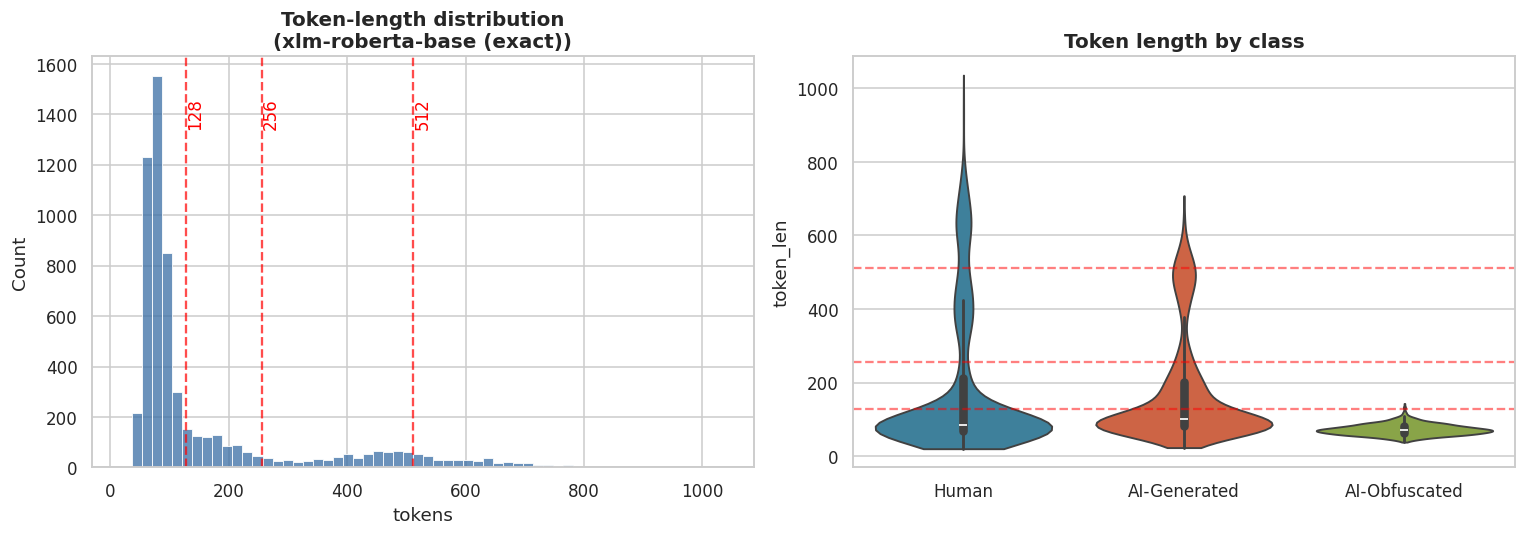

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['token_len'], bins=60, color='#3A6EA5', ax=axes[0])
for L in MAX_LENS:
    axes[0].axvline(L, color='red', linestyle='--', alpha=0.7)
    axes[0].text(L, axes[0].get_ylim()[1] * 0.9, str(L), color='red', rotation=90, va='top')
axes[0].set_title(f'Token-length distribution\n({token_source})')
axes[0].set_xlabel('tokens')
sns.violinplot(data=df, x='label_name', y='token_len', order=CLASS_ORDER, palette=PALETTE, cut=0, ax=axes[1])
for L in MAX_LENS:
    axes[1].axhline(L, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Token length by class')
axes[1].set_xlabel('')
fig.tight_layout()
save_fig(fig, 'token_length')
plt.show()


## 10. Embedding visualization

We embed a stratified sample of texts with a multilingual Sentence-Transformer
(`paraphrase-multilingual-MiniLM-L12-v2`, which supports Kazakh) and project to 2-D with PCA, t-SNE, and UMAP,
colouring points by class. Well-separated clusters suggest the classes are linearly/semantically distinguishable;
heavy overlap (expected especially between Human-Written
 and AI-Obfuscated) foreshadows a harder classification problem.
This step is guarded by `RUN_HEAVY` and uses stratified sampling to stay tractable on CPU.


In [22]:
if RUN_HEAVY:
    try:
        from sentence_transformers import SentenceTransformer
        from sklearn.decomposition import PCA
        from sklearn.manifold import TSNE

        per_class = 500
        sample = (df.groupby('label_name', group_keys=False)
                    .apply(lambda g: g.sample(min(len(g), per_class), random_state=RANDOM_SEED)))
        model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
        emb = model.encode(sample['text'].tolist(), batch_size=32, show_progress_bar=True,
                           normalize_embeddings=True)

        projections = {}
        projections['PCA'] = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(emb)
        projections['t-SNE'] = TSNE(n_components=2, random_state=RANDOM_SEED, init='pca',
                                    perplexity=30).fit_transform(emb)
        try:
            import umap
            projections['UMAP'] = umap.UMAP(n_components=2, random_state=RANDOM_SEED).fit_transform(emb)
        except Exception as ue:
            print('UMAP unavailable (pip install umap-learn):', ue)

        fig, axes = plt.subplots(1, len(projections), figsize=(6.5 * len(projections), 5.5))
        if len(projections) == 1:
            axes = [axes]
        labels = sample['label_name'].values
        for ax, (name, xy) in zip(axes, projections.items()):
            for cls in CLASS_ORDER:
                m = labels == cls
                ax.scatter(xy[m, 0], xy[m, 1], s=10, alpha=0.6, color=PALETTE[cls], label=cls)
            ax.set_title(name)
            ax.legend(fontsize=8)
        fig.suptitle('Sentence-embedding projections (coloured by class)', y=1.02,
                     fontsize=15, fontweight='bold')
        fig.tight_layout()
        save_fig(fig, 'embedding_projections')
        plt.show()
    except Exception as e:
        print('Embedding step failed:', e)
        print('Install with: pip install sentence-transformers umap-learn')
else:
    print('RUN_HEAVY is False: skipping embedding visualization. Set RUN_HEAVY=True to run it.')


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 11. Statistical testing

We test whether the classes differ on the engineered features using non-parametric tests (the features are
heavily skewed, so rank-based tests are appropriate). The Kruskal-Wallis test checks whether at least one class
differs for each feature (with epsilon-squared as effect size); pairwise Mann-Whitney U tests localise the
differences (with rank-biserial correlation as effect size); and a chi-square test of independence checks
whether the `source` category is associated with the label (with Cramer's V as effect size). We report p-values
and effect sizes rather than relying on significance alone, since large n makes almost everything significant.


In [ ]:
from scipy import stats

groups = {name: df.loc[df['label_name'] == name] for name in CLASS_ORDER}
n_total = len(df)
k_groups = len(CLASS_ORDER)

# Kruskal-Wallis across the three classes for every numeric feature.
kw_rows = []
for feat in NUMERIC_FEATURES:
    samples = [groups[name][feat].values for name in CLASS_ORDER]
    H, p = stats.kruskal(*samples)
    epsilon_sq = (H - k_groups + 1) / (n_total - k_groups)   # bias-corrected epsilon^2
    kw_rows.append({'feature': feat, 'H': round(H, 2), 'p_value': p,
                    'epsilon_squared': round(max(epsilon_sq, 0.0), 4)})
kw_res = pd.DataFrame(kw_rows).sort_values('epsilon_squared', ascending=False).set_index('feature')
save_table(kw_res, '11_kruskal_wallis')
print('Kruskal-Wallis (classes differ per feature), sorted by effect size:')
print(kw_res)


In [ ]:
from itertools import combinations

def rank_biserial(a: np.ndarray, b: np.ndarray, U: float) -> float:
    # Effect size for Mann-Whitney U: r = 1 - 2U/(n1*n2).
    return 1.0 - (2.0 * U) / (len(a) * len(b))

mw_rows = []
for feat in ['word_count', 'char_count', 'lexical_diversity', 'punct_ratio', 'avg_word_len', 'stopword_ratio']:
    for a_name, b_name in combinations(CLASS_ORDER, 2):
        a = groups[a_name][feat].values
        b = groups[b_name][feat].values
        U, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        mw_rows.append({'feature': feat, 'pair': f'{a_name} vs {b_name}',
                        'U': U, 'p_value': p, 'rank_biserial': round(rank_biserial(a, b, U), 4)})
mw_res = pd.DataFrame(mw_rows)
save_table(mw_res.set_index(['feature', 'pair']), '11_mann_whitney_pairwise')
print('Pairwise Mann-Whitney U (selected features):')
print(mw_res.to_string(index=False))


In [ ]:
def cramers_v(confusion: np.ndarray) -> float:
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.sum()
    r, c = confusion.shape
    return float(np.sqrt(chi2 / (n * (min(r, c) - 1))))

# Chi-square: is the source category associated with the label? (expected to be strong by construction)
ct_source = pd.crosstab(df['source'], df['label_name'])
chi2, p_src, dof, _ = stats.chi2_contingency(ct_source.values)
print(f'Source vs label : chi2={chi2:.1f}, dof={dof}, p={p_src:.3e}, Cramers V={cramers_v(ct_source.values):.3f}')

# Chi-square: is the split associated with the label? (should be weak if splits are stratified)
ct_split = pd.crosstab(df['split'], df['label_name'])
chi2s, p_split, dofs, _ = stats.chi2_contingency(ct_split.values)
print(f'Split vs label  : chi2={chi2s:.1f}, dof={dofs}, p={p_split:.3e}, Cramers V={cramers_v(ct_split.values):.3f}')

chi_summary = pd.DataFrame({
    'test': ['source_vs_label', 'split_vs_label'],
    'chi2': [round(chi2, 2), round(chi2s, 2)],
    'dof': [dof, dofs],
    'p_value': [p_src, p_split],
    'cramers_v': [round(cramers_v(ct_source.values), 4), round(cramers_v(ct_split.values), 4)],
}).set_index('test')
save_table(chi_summary, '11_chi_square')
chi_summary


## 12. Correlation analysis

We examine relationships among the numeric features with a Spearman correlation heatmap (rank-based, robust to
skew), a pairplot on a manageable subset of the most informative features, and a quick supervised
feature-importance overview from a Random Forest trained to predict the label from the engineered features. The
importance view indicates which cheap linguistic features carry the most class signal for a baseline model.


In [ ]:
corr = df[NUMERIC_FEATURES].corr(method='spearman')
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8}, annot_kws={'size': 7}, ax=ax)
ax.set_title('Spearman correlation among numeric features')
fig.tight_layout()
save_fig(fig, 'correlation_heatmap')
plt.show()
save_table(corr.round(3), '12_correlation_matrix')


In [ ]:
pair_feats = ['word_count', 'lexical_diversity', 'avg_word_len', 'punct_ratio']
sample_pp = df.sample(min(900, len(df)), random_state=RANDOM_SEED)
g = sns.pairplot(sample_pp, vars=pair_feats, hue='label_name', hue_order=CLASS_ORDER,
                 palette=PALETTE, corner=True, plot_kws={'s': 12, 'alpha': 0.5})
g.fig.suptitle('Pairwise relationships (sampled)', y=1.02, fontsize=14, fontweight='bold')
save_fig(g.fig, 'pairplot')
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

train_mask = df['split'] == 'train'
X_train = df.loc[train_mask, NUMERIC_FEATURES].values
y_train = df.loc[train_mask, 'label'].values
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=NUMERIC_FEATURES).sort_values()
save_table(importances.to_frame('importance'), '12_feature_importance')
fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', color='#2A9D8F', ax=ax)
ax.set_title('Random-Forest feature importance (predicting label from linguistic features)')
ax.set_xlabel('importance')
fig.tight_layout()
save_fig(fig, 'feature_importance')
plt.show()


## 13. Outlier detection

We detect anomalous documents two ways: a univariate IQR rule on length (word/char counts), and a multivariate
Isolation Forest over all standardised numeric features. Outliers are often extremely short/long texts, templated
content, or data-collection artefacts; inspecting them guides cleaning decisions before modelling.


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def iqr_outliers(series: pd.Series, k: float = 1.5) -> pd.Series:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)

df['iqr_outlier_words'] = iqr_outliers(df['word_count'])
df['iqr_outlier_chars'] = iqr_outliers(df['char_count'])

Xs = StandardScaler().fit_transform(df[NUMERIC_FEATURES].values)
iso = IsolationForest(n_estimators=300, contamination=0.03, random_state=RANDOM_SEED, n_jobs=-1)
df['iso_outlier'] = iso.fit_predict(Xs) == -1

outlier_summary = pd.DataFrame({
    'iqr_words': df.groupby('label_name')['iqr_outlier_words'].sum(),
    'iqr_chars': df.groupby('label_name')['iqr_outlier_chars'].sum(),
    'isolation_forest': df.groupby('label_name')['iso_outlier'].sum(),
}).reindex(CLASS_ORDER).astype(int)
print('Total Isolation-Forest outliers:', int(df['iso_outlier'].sum()))
save_table(outlier_summary, '13_outlier_summary')
print(outlier_summary)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
normal = df[~df['iso_outlier']]
outl = df[df['iso_outlier']]
axes[0].scatter(normal['word_count'], normal['char_count'], s=8, alpha=0.35, color='#8ecae6', label='normal')
axes[0].scatter(outl['word_count'], outl['char_count'], s=18, alpha=0.8, color='#d00000', label='outlier')
axes[0].set_xlabel('word_count')
axes[0].set_ylabel('char_count')
axes[0].set_title('Isolation-Forest outliers (length space)')
axes[0].legend()
outlier_summary.plot(kind='bar', ax=axes[1])
axes[1].set_title('Outlier counts by class and method')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', labelrotation=0)
fig.tight_layout()
save_fig(fig, 'outliers')
plt.show()


In [ ]:
# Persist the engineered per-document feature table for downstream modelling / reproducibility.
export_cols = ['split', 'label', 'label_name', 'source'] + NUMERIC_FEATURES + ['token_len', 'ari', 'syll_per_word']
export_cols = [c for c in export_cols if c in df.columns]
df[export_cols].to_csv(OUTPUT_DIR / 'engineered_features.csv', index=False)
print('Saved engineered feature table to', OUTPUT_DIR / 'engineered_features.csv')
print('Figures:', len(list(FIG_DIR.glob('*.png'))), '| Tables:', len(list(TAB_DIR.glob('*.csv'))))


In [ ]:
import shutil
from pathlib import Path

# Folder to zip
output_dir = Path("eda_outputs")

# Create ZIP archive
shutil.make_archive(
    base_name="eda_outputs",  # Output: eda_outputs.zip
    format="zip",
    root_dir=output_dir
)

print("✅ ZIP file created:", Path("eda_outputs.zip").resolve())